In [1]:

!pip install seaborn
!pip install nltk
!pip install pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import pickle

In [2]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vishnu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vishnu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df=pd.read_csv('question_difficulty_dataset_5000.csv')
df

,question_id,question_text,difficulty_level
0,1,Describe the working of Linear Regression.,Medium
1,2,Analyze the performance of Random Forest under...,Hard
2,3,Describe the working of K-Means Clustering.,Medium
3,4,What is Logistic Regression?,Easy
4,5,What is Bayesian Networks?,Easy
...,...,...,...
4995,4996,Compare Random Forest and Neural Networks with...,Hard
4996,4997,What do you mean by Neural Networks?,Easy
4997,4998,Analyze the performance of Deep Learning under...,Hard
4998,4999,Describe the working of Natural Language Proce...,Medium


In [6]:
df.dropna(inplace=True)
df

,question_id,question_text,difficulty_level
0,1,Describe the working of Linear Regression.,Medium
1,2,Analyze the performance of Random Forest under...,Hard
2,3,Describe the working of K-Means Clustering.,Medium
3,4,What is Logistic Regression?,Easy
4,5,What is Bayesian Networks?,Easy
...,...,...,...
4995,4996,Compare Random Forest and Neural Networks with...,Hard
4996,4997,What do you mean by Neural Networks?,Easy
4997,4998,Analyze the performance of Deep Learning under...,Hard
4998,4999,Describe the working of Natural Language Proce...,Medium


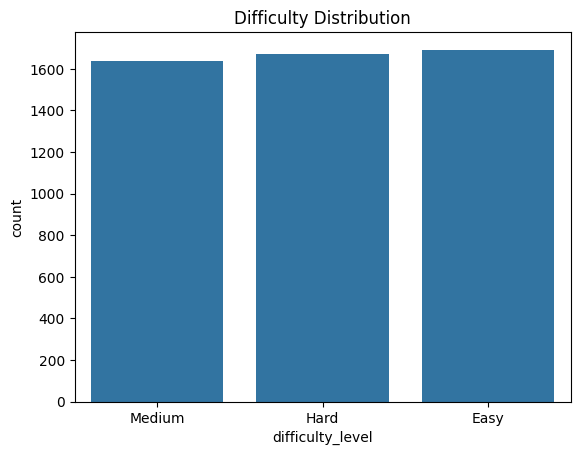

In [7]:
sns.countplot(x='difficulty_level', data=df)
plt.title("Difficulty Distribution")
plt.show()

In [8]:
text = df["question_text"].str.lower()
text = text.replace('[^a-zA-Z]', ' ', regex=True)

In [9]:
text = text.apply(lambda x: ' '.join(
    [w for w in word_tokenize(x) if len(w) >= 3]
))
text

0                  describe the working linear regression
1       analyze the performance random forest under di...
2                   describe the working means clustering
3                                what logistic regression
4                                  what bayesian networks
                              ...                        
4995    compare random forest and neural networks with...
4996                        what you mean neural networks
4997    analyze the performance deep learning under di...
4998     describe the working natural language processing
4999                 describe the working neural networks
Name: question_text, Length: 5000, dtype: object

In [10]:
# Remove empty strings
text = text[text.str.strip() != ""]
df = df.loc[text.index]


In [ ]:
text

0                  describe the working linear regression
1       analyze the performance random forest under di...
2                   describe the working means clustering
3                                what logistic regression
4                                  what bayesian networks
                              ...                        
4995    compare random forest and neural networks with...
4996                        what you mean neural networks
4997    analyze the performance deep learning under di...
4998     describe the working natural language processing
4999                 describe the working neural networks
Name: question_text, Length: 5000, dtype: str

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [12]:
X = tfidf.fit_transform(text)

In [13]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df["difficulty_level"])

le.classes_   # just to verify


array(['Easy', 'Hard', 'Medium'], dtype=object)

In [14]:
#train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)


In [15]:
#train the model using naive bayes
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:
y_pred = model.predict(X_test)
y_pred

array([1, 2, 1, 2, 1, 1, 0, 0, 1, 1, 2, 2, 1, 2, 0, 1, 0, 0, 0, 0, 2, 0,
       1, 0, 2, 0, 1, 2, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 0, 1, 2, 0,
       0, 2, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2, 2, 2, 1, 2, 0, 0, 1, 1, 2, 0,
       1, 2, 2, 0, 0, 0, 2, 0, 2, 1, 2, 0, 0, 1, 1, 0, 1, 1, 0, 0, 2, 2,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 2, 1, 1, 2, 2,
       1, 1, 0, 0, 0, 2, 0, 0, 2, 0, 2, 2, 0, 1, 1, 1, 2, 2, 2, 0, 0, 2,
       0, 2, 0, 1, 0, 2, 2, 1, 1, 0, 0, 2, 1, 0, 2, 2, 2, 2, 1, 2, 1, 0,
       2, 0, 1, 1, 1, 0, 1, 0, 0, 0, 2, 2, 1, 2, 2, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 2, 1, 0, 1, 1, 1, 2, 1, 0, 0, 0, 0, 1, 2, 0, 1, 1, 1, 0, 0,
       1, 2, 1, 2, 1, 1, 1, 1, 0, 1, 1, 2, 2, 2, 0, 0, 0, 2, 1, 1, 0, 1,
       0, 2, 0, 1, 0, 0, 0, 2, 2, 2, 2, 1, 0, 2, 2, 2, 2, 0, 1, 2, 2, 2,
       1, 1, 1, 0, 1, 1, 2, 0, 0, 2, 1, 0, 0, 0, 2, 2, 1, 0, 0, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 0, 1, 2, 2, 2, 0, 1, 2, 2, 1, 0, 1, 0, 0,
       2, 0, 1, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 1, 1,

In [17]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 99.00%


In [18]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))


              precision    recall  f1-score   support

        Easy       1.00      0.97      0.98       338
        Hard       1.00      1.00      1.00       335
      Medium       0.97      1.00      0.98       327

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [19]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[328,   0,  10],
       [  0, 335,   0],
       [  0,   0, 327]])

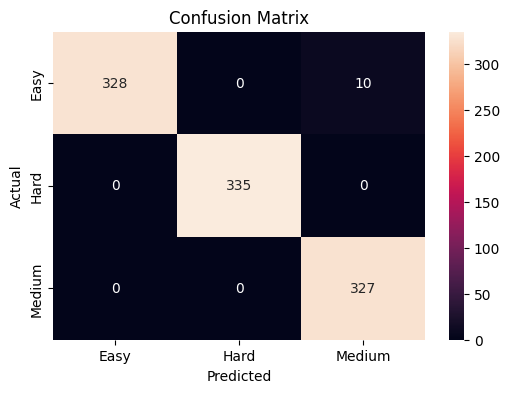

In [20]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
df = df.dropna().reset_index(drop=True)

In [22]:
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("✅ Model files saved successfully")

✅ Model files saved successfully
